# Nigeria Climate Data Analysis (2015–2026)

## Objective
This notebook analyzes climate data to identify trends and patterns.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The dataset is loaded from a local CSV file. A new column is added to indicate the country for easier identification during analysis.

In [2]:
df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


## Date Conversion

The dataset provides YEAR and DOY (Day of Year). These are combined to create a proper datetime column, which is necessary for time series analysis. A Month column is also extracted for seasonal analysis.

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Handling Missing Values

The dataset may contain -999 values, which represent missing or invalid data from the source. These are replaced with NaN to avoid distortion in statistical analysis.

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


## Duplicate Records

We check for duplicate rows in the dataset to ensure data integrity.

In [5]:
duplicates = df.duplicated().sum()
duplicates

df.drop_duplicates(inplace=True)


duplicate rows were detected and removed.

## Summary Statistics

Basic descriptive statistics are computed to understand the distribution of climate variables such as temperature, precipitation, and humidity.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Interpretation

- The mean temperature (T2M) indicates generally mild to warm conditions.
- The maximum temperature (T2M_MAX) shows occasional high-temperature extremes, which may indicate heat stress periods.
- Precipitation (PRECTOTCORR) appears highly variable, suggesting seasonal rainfall patterns.
- Relative humidity (RH2M) values suggest moderate atmospheric moisture levels.

## Missing Value Analysis

We evaluate the number and percentage of missing values in each column to assess data quality.

In [8]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with more than 5% missing values may require careful handling, such as imputation or exclusion, depending on their importance to the analysis. We have no missing values here.

## Outlier Detection

Z-scores are used to identify extreme values in selected climate variables. Observations with absolute Z-score greater than 3 are considered potential outliers.

In [9]:
import scipy
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64

### Outlier Analysis Interpretation

The outlier analysis reveals that humidity and precipitation variables contain the highest number of anomalies, suggesting irregular or extreme measurements.
Temperature minimum values also show notable outliers, pointing to unusual cold events.
Identifying these anomalies is crucial for ensuring data quality and for understanding rare but impactful climate extremes.

## Handling Missing Values

Missing values are handled using forward-fill for continuous weather variables. Rows with excessive missing data may be dropped to maintain data quality.

In [10]:
##df.fillna(method='ffill', inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


Forward-fill is applied to preserve temporal continuity in the dataset. This approach assumes that short gaps in measurements can be approximated using previous observations.

Rows with excessive missing values are removed to avoid unreliable analysis.

In [11]:
df.to_csv("../data/nigeria_clean.csv", index=False)

The cleaned dataset is saved for further analysis and cross-country comparison.

## Temperature Trend Analysis

We analyze monthly average temperature (T2M) over time to identify long-term trends and seasonal patterns.

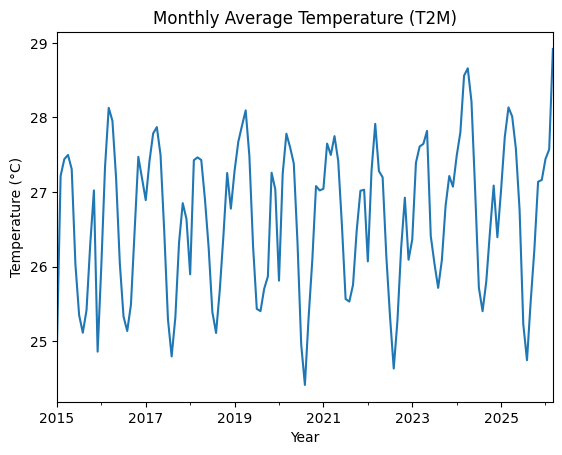

In [12]:
# Create a time-indexed DataFrame
df_time = df.set_index("Date")

# Monthly average temperature
monthly_temp = df_time["T2M"].resample("ME").mean()

# Plot
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

### Temperature Trend Interpretation

The temperature trend shows consistent seasonal fluctuations across the years, with regular peaks and troughs indicating a stable annual cycle.
Temperatures generally remain within a narrow range, suggesting a relatively stable climate without significant long-term warming or cooling trends.
This stability indicates predictable temperature conditions, which are important for agriculture and environmental planning.

## Seasonal Temperature Pattern

To better understand seasonal behavior, we examine the average temperature for each month across all years.

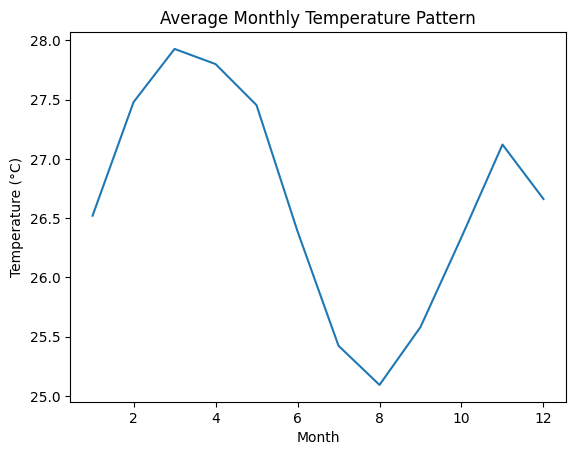

In [13]:
monthly_temp_pattern = df.groupby("Month")["T2M"].mean()

plt.figure()
monthly_temp_pattern.plot()
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Seasonal Temperature Pattern Interpretation

The monthly temperature pattern follows a sinusoidal curve, with warmest conditions mid-year and cooler conditions at the beginning and end of the year.
This predictable cycle reflects the influence of seasonal climate drivers.
Such regularity supports planning for temperature-sensitive activities like planting and harvesting.

## Precipitation Analysis

We examine monthly total precipitation to identify rainfall patterns and seasonal peaks.

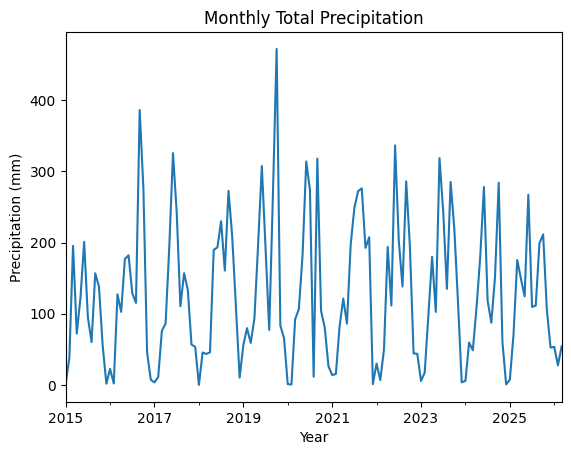

In [14]:
monthly_rain = df_time["PRECTOTCORR"].resample("ME").sum()

plt.figure()
monthly_rain.plot()
plt.title("Monthly Total Precipitation")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.show()

### Precipitation Trend Interpretation

The precipitation trend reveals variability across years, with certain periods experiencing unusually high rainfall.
Despite fluctuations, the overall seasonal pattern remains consistent, with wet and dry months repeating annually.
This cyclical behavior highlights the importance of rainfall seasonality for water resource management and crop planning.

## Seasonal Precipitation Pattern

We examine the average precipitation for each month to better understand the timing and concentration of rainy seasons.

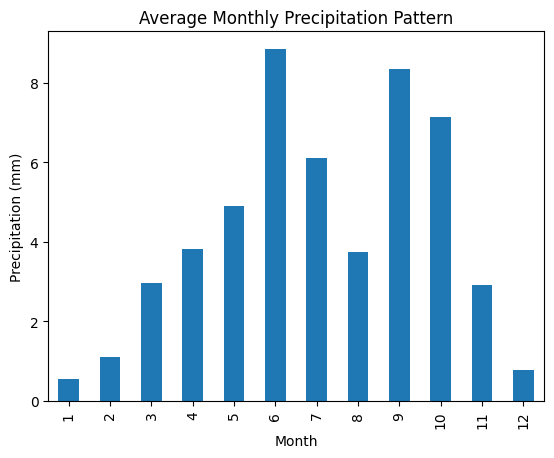

In [15]:
monthly_rain_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain_pattern.plot(kind="bar")
plt.title("Average Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

### Seasonal Precipitation Pattern Interpretation

The monthly precipitation pattern shows distinct rainy and dry seasons.
Certain months consistently record higher rainfall, while others remain relatively dry.
This seasonal distribution is critical for irrigation scheduling, flood preparedness, and agricultural productivity.

## Correlation Analysis

We examine relationships between key climate variables using a correlation matrix. This helps identify how different environmental factors interact with each other.

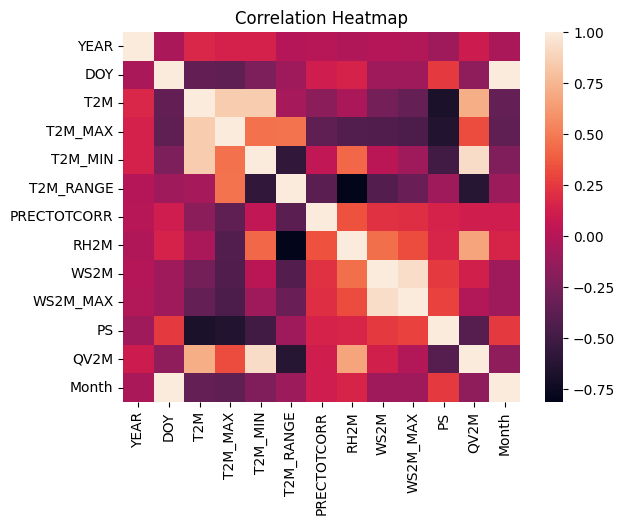

In [16]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap highlights strong negative relationships between temperature and humidity, confirming that hotter conditions tend to be drier.
Precipitation is positively correlated with humidity, reinforcing the link between moisture and rainfall events.
Wind speed shows weaker correlations, suggesting it plays a secondary role in shaping climate variability.

## Variable Relationships

Scatter plots are used to further explore relationships between key variables identified in the correlation analysis.

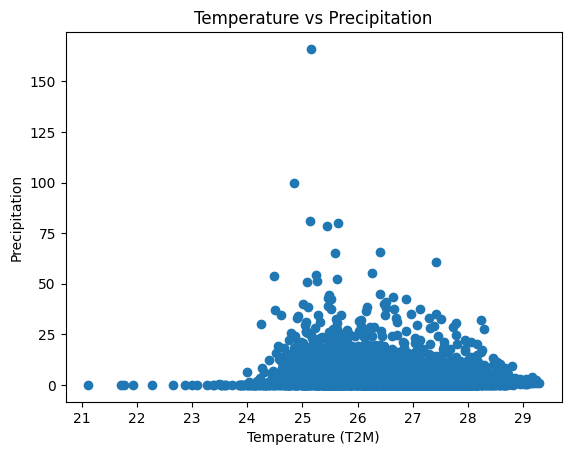

In [17]:
plt.figure()
plt.scatter(df["T2M"], df["PRECTOTCORR"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

### Temperature vs Precipitation Interpretation

The relationship between temperature and precipitation indicates that rainfall tends to occur at moderate temperature ranges.
Extreme temperatures (very high or very low) are less associated with rainfall.
This suggests that moderate climate conditions are more favorable for precipitation events.

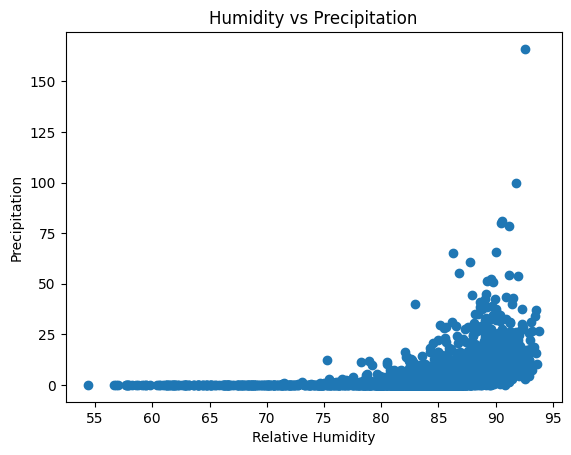

In [18]:
plt.figure()
plt.scatter(df["RH2M"], df["PRECTOTCORR"])
plt.xlabel("Relative Humidity")
plt.ylabel("Precipitation")
plt.title("Humidity vs Precipitation")
plt.show()

### Humidity vs Precipitation Interpretation

The scatter plot demonstrates a clear positive relationship between humidity and precipitation.
Higher humidity levels consistently align with greater rainfall amounts.
This reinforces the role of atmospheric moisture as a key driver of rainfall intensity.

## Precipitation Distribution Analysis

To better understand the distribution of precipitation, a histogram is plotted. Since precipitation data is typically highly skewed, a logarithmic transformation is applied to improve visualization and highlight underlying patterns.

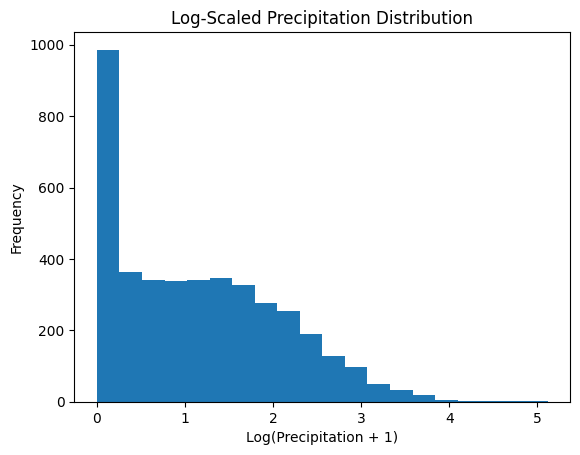

In [19]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"]), bins=20)
plt.title("Log-Scaled Precipitation Distribution")
plt.xlabel("Log(Precipitation + 1)")
plt.ylabel("Frequency")
plt.show()

The log-scaled histogram shows that most precipitation events are small, but a few extreme rainfall events skew the distribution.
Log scaling helps reveal the frequency of smaller events while controlling for the impact of rare extremes.
This distribution highlights the importance of preparing for occasional heavy rainfall despite most events being moderate.

## Multivariable Relationship Analysis

A bubble chart is used to examine the relationship between temperature (T2M) and relative humidity (RH2M), with precipitation represented by the size of the bubbles.

This visualization helps capture how multiple climate variables interact simultaneously, providing deeper insight into the conditions associated with rainfall events.

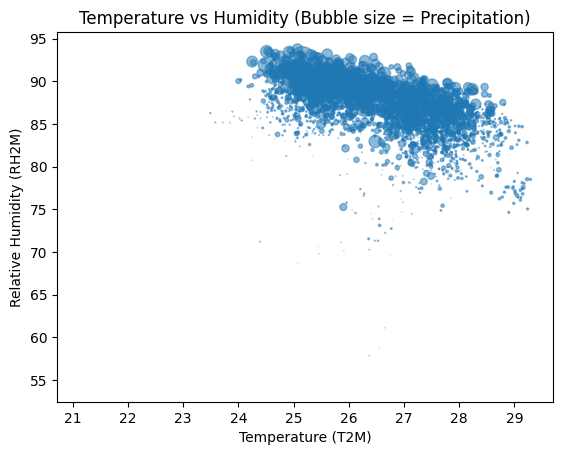

In [20]:
plt.figure()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,  # scale bubbles
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Temperature vs Humidity (Bubble size = Precipitation)")
plt.show()

### Bubble Chart Interpretation

The bubble chart shows that higher humidity levels often coincide with rainfall events, represented by larger bubbles.
This confirms that precipitation is strongly tied to moist atmospheric conditions.
Moderate temperatures appear most conducive to rainfall, rather than extreme heat or cold.

## Key Insights

Temperature
Nigeria’s temperature shows stable seasonal cycles, with predictable peaks mid-year and troughs at the start and end of each year.

The narrow range of variation suggests a relatively stable climate, without strong evidence of long-term warming or cooling trends.

This stability provides predictable conditions for agriculture and environmental planning.

Precipitation
Rainfall patterns reveal distinct wet and dry seasons, with certain months consistently wetter.

Year-to-year variability exists, including occasional extreme rainfall events, but the overall seasonal rhythm remains intact.

These cycles are critical for water resource management, irrigation scheduling, and flood preparedness.

Humidity & Correlations
Humidity strongly correlates with precipitation, confirming that rainfall events are tied to moist atmospheric conditions.
Temperature and humidity show a negative relationship: hotter periods tend to be drier.

Wind speed plays a secondary role, with weaker correlations to other variables.

Extremes & Outliers
Outlier analysis highlights unusual cold events (minimum temperature anomalies) and extreme rainfall/humidity spikes.

While rare, these anomalies are important for disaster preparedness and climate resilience planning.

Overall Climate Dynamics
Nigeria’s climate is characterized by predictable seasonal cycles in temperature and rainfall, strong humidity–precipitation coupling, and occasional extreme events.

These insights reinforce the importance of seasonal forecasting, agricultural planning, and infrastructure resilience to manage both regular cycles and rare extremes.